In [7]:
import gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

# fixing for colabs numpy 2.0 ---
np.bool8 = np.bool_
# -------------------------------------

# set to gpu if can
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super(Actor, self).__init__()

        # Architecture: 2 hidden layers
        self.l1 = nn.Linear(state_dim, 400)
        self.l2 = nn.Linear(400, 300)
        self.l3 = nn.Linear(300, action_dim)

        self.max_action = max_action

    def forward(self, state):
        a = F.relu(self.l1(state))
        a = F.relu(self.l2(a))
        # scale the bounded output to the environment's max action
        return self.max_action * torch.tanh(self.l3(a))


class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()

        # our critic concatenates state and action at the input layer
        self.l1 = nn.Linear(state_dim + action_dim, 400)
        self.l2 = nn.Linear(400, 300)
        self.l3 = nn.Linear(300, 1)

    def forward(self, state, action):
        # concatenate along the feature dimension
        sa = torch.cat([state, action], 1)

        q = F.relu(self.l1(sa))
        q = F.relu(self.l2(q))
        return self.l3(q)

In [3]:
class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        # store experience as a tuple
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        # randomly sample a batch of experiences
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.stack, zip(*batch))

        # convert to PyTorch tensors and send to the correct device
        return (
            torch.FloatTensor(state).to(device),
            torch.FloatTensor(action).to(device),
            torch.FloatTensor(reward).unsqueeze(1).to(device),
            torch.FloatTensor(next_state).to(device),
            torch.FloatTensor(done).unsqueeze(1).to(device)
        )

    def __len__(self):
        return len(self.buffer)

In [4]:
class DDPGAgent:
    def __init__(self, state_dim, action_dim, max_action):
        # initialize Actor and its target
        self.actor = Actor(state_dim, action_dim, max_action).to(device)
        self.actor_target = Actor(state_dim, action_dim, max_action).to(device)
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=1e-4)

        # initialize Critic and its target
        self.critic = Critic(state_dim, action_dim).to(device)
        self.critic_target = Critic(state_dim, action_dim).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=1e-3)

        self.max_action = max_action
        self.memory = ReplayBuffer()

        # our hyperparameters
        self.batch_size = 64
        self.gamma = 0.99   # Discount factor
        self.tau = 0.005    # Soft update rate

    def select_action(self, state):
        # forward pass through the Actor to get an action
        state = torch.FloatTensor(state.reshape(1, -1)).to(device)
        return self.actor(state).cpu().data.numpy().flatten()

    def train(self):
        # only start training once we have enough samples in the buffer
        if len(self.memory) < self.batch_size:
            return 0, 0

        # Sample a batch of experiences
        state, action, reward, next_state, done = self.memory.sample(self.batch_size)

        # -----------------------
        # Train Critic
        # -----------------------
        # get next action from target actor, and next Q from target critic
        next_action = self.actor_target(next_state)
        target_Q = self.critic_target(next_state, next_action)

        # Bellman equation: target_Q = reward + gamma * target_Q * (1 - done)
        target_Q = reward + ((1 - done) * self.gamma * target_Q).detach()

        # get current Q estimate
        current_Q = self.critic(state, action)

        # compute critic loss (Mean Squared Error)
        critic_loss = F.mse_loss(current_Q, target_Q)

        # optimize the critic (Backward path)
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # -----------------------
        # Train Actor
        # -----------------------
        # compute actor loss: We want to maximize the Q-value, so we minimize the negative Q-value
        actor_loss = -self.critic(state, self.actor(state)).mean()

        # optimize the actor (Backward path)
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # -----------------------
        # Soft Update Targets
        # -----------------------
        # slowly blend the primary network weights into the target networks
        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

        for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

        return critic_loss.item(), actor_loss.item()

In [5]:
class OUNoise:
    """Ornstein-Uhlenbeck process for action exploration."""
    def __init__(self, action_dimension, mu=0.0, theta=0.15, sigma=0.2):
        self.action_dimension = action_dimension
        self.mu = mu
        self.theta = theta
        self.sigma = sigma
        self.state = np.ones(self.action_dimension) * self.mu
        self.reset()

    def reset(self):
        self.state = np.ones(self.action_dimension) * self.mu

    def sample(self):
        x = self.state
        # calculate the drift
        dx = self.theta * (self.mu - x) + self.sigma * np.random.randn(len(x))
        self.state = x + dx
        return self.state

In [8]:
# initialize environment and explicitly use the new API to stop warnings
env = gym.make('Pendulum-v1', new_step_api=True)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
max_action = float(env.action_space.high[0])

# instantiate agent and noise process
agent = DDPGAgent(state_dim, action_dim, max_action)
noise = OUNoise(action_dim)

# hyperparameters for training loop
episodes = 250
max_steps = 200 # Pendulum-v1 truncates at 200 steps

# tracking lists for your report's visualizations
reward_history = []
critic_loss_history = []

print("Starting DDPG Training on Pendulum-v1...")

for episode in range(episodes):
    state = env.reset()
    # handle Gym API differences (v0.26+ returns a tuple (state, info))
    if isinstance(state, tuple):
        state = state[0]

    noise.reset()
    episode_reward = 0
    episode_critic_loss = []

    for step in range(max_steps):
        # 1. select action and add OU exploration noise
        action = agent.select_action(state)
        action = action + noise.sample()
        # ensure the action stays within the allowed bounds [-2.0, 2.0]
        action = np.clip(action, -max_action, max_action)

        # 2. step the environment
        step_result = env.step(action)
        # handle Gym API differences (v0.26+ adds 'truncated' flag)
        if len(step_result) == 4:
            next_state, reward, done, _ = step_result
        else:
            next_state, reward, terminated, truncated, _ = step_result
            done = terminated or truncated

        # 3. store experience in Replay Buffer
        agent.memory.push(state, action, reward, next_state, done)

        # 4. train the agent
        c_loss, a_loss = agent.train()

        # only record loss once the buffer has enough samples to start training
        if c_loss != 0:
            episode_critic_loss.append(c_loss)

        state = next_state
        episode_reward += reward

        if done:
            break

    # calculate episode statistics
    reward_history.append(episode_reward)
    avg_c_loss = np.mean(episode_critic_loss) if episode_critic_loss else 0
    critic_loss_history.append(avg_c_loss)

    # print progress to the Colab console
    if (episode + 1) % 10 == 0:
        print(f"Episode: {episode+1}/{episodes} | Total Reward: {episode_reward:.2f} | Avg Critic Loss: {avg_c_loss:.4f}")

env.close()
print("Training Complete!")

Starting DDPG Training on Pendulum-v1...
Episode: 10/250 | Total Reward: -1400.30 | Avg Critic Loss: 17.9610
Episode: 20/250 | Total Reward: -934.68 | Avg Critic Loss: 49.9011
Episode: 30/250 | Total Reward: -876.73 | Avg Critic Loss: 82.0018
Episode: 40/250 | Total Reward: -1354.48 | Avg Critic Loss: 108.5165
Episode: 50/250 | Total Reward: -126.43 | Avg Critic Loss: 103.8143
Episode: 60/250 | Total Reward: -455.52 | Avg Critic Loss: 109.6719
Episode: 70/250 | Total Reward: -135.43 | Avg Critic Loss: 86.9180
Episode: 80/250 | Total Reward: -249.18 | Avg Critic Loss: 65.2479
Episode: 90/250 | Total Reward: -119.99 | Avg Critic Loss: 56.6287
Episode: 100/250 | Total Reward: -118.90 | Avg Critic Loss: 53.1839
Episode: 110/250 | Total Reward: -120.90 | Avg Critic Loss: 35.6616
Episode: 120/250 | Total Reward: -125.77 | Avg Critic Loss: 24.9446
Episode: 130/250 | Total Reward: -2.82 | Avg Critic Loss: 33.8343
Episode: 140/250 | Total Reward: -248.14 | Avg Critic Loss: 30.1531
Episode: 150/

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1987: PyparsingDeprecationWarning: 'setParseA

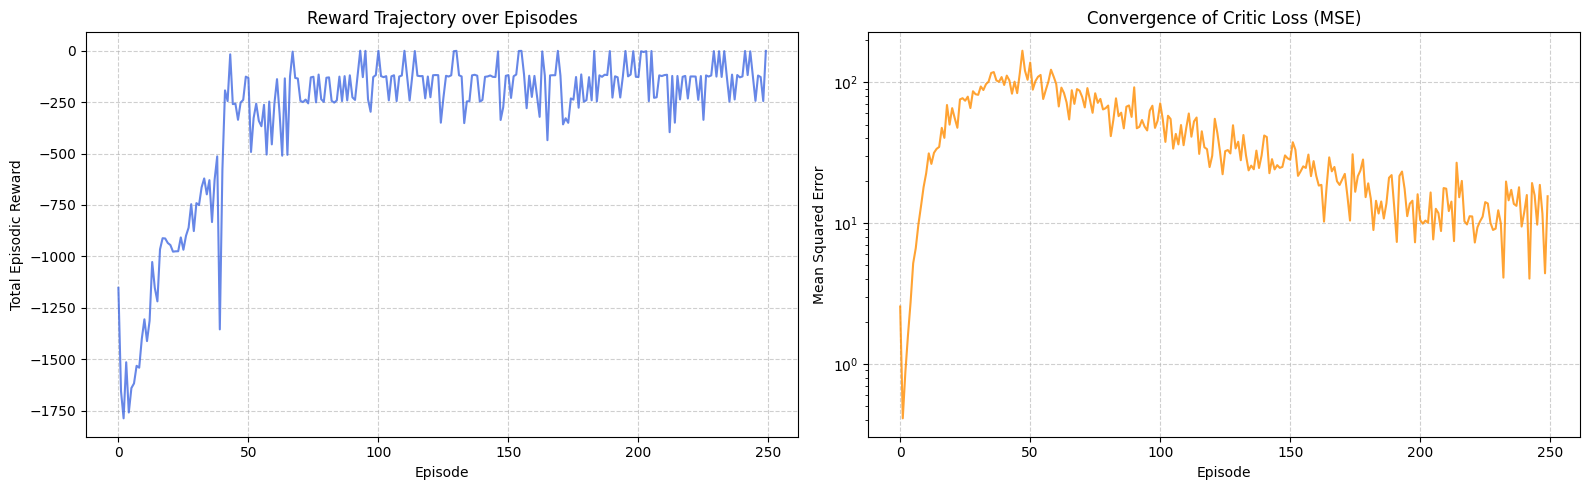

In [9]:
def plot_results(rewards, critic_losses):
    fig, axs = plt.subplots(1, 2, figsize=(16, 5))

    # plot 1: Reward Trajectories
    # a successful DDPG agent on Pendulum-v1 will converge toward a score between -100 and -300
    axs[0].plot(rewards, color='royalblue', alpha=0.8)
    axs[0].set_title('Reward Trajectory over Episodes')
    axs[0].set_xlabel('Episode')
    axs[0].set_ylabel('Total Episodic Reward')
    axs[0].grid(True, linestyle='--', alpha=0.6)

    # plot 2: Convergence of Loss Function
    # we plot the Critic (MSE) loss, as the Actor loss in DDPG is technically just a gradient direction
    axs[1].plot(critic_losses, color='darkorange', alpha=0.8)
    axs[1].set_title('Convergence of Critic Loss (MSE)')
    axs[1].set_xlabel('Episode')
    axs[1].set_ylabel('Mean Squared Error')
    axs[1].set_yscale('log') # log scale makes the convergence drop much easier to see
    axs[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# generate the plots
plot_results(reward_history, critic_loss_history)